<a href="https://colab.research.google.com/github/Seif-Abouelkhair/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Seif-Abouelkhair/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Research question

Which safe search and content signals can be used to identify pages that are at higher risk of declining performance, so that they can be prioritized for review and refresh?

Decision supported

The goal is to support a practical content-review decision: which pages should be reviewed first for a possible refresh, improvement, or monitoring action?

This is a decision-support model rather than a claim about how Google's ranking system works. The analysis measures patterns observed in the available FlyRank search data and uses those patterns to produce a ranked list of content opportunities.

In [1]:
%pip -q install duckdb huggingface_hub

In [2]:
import os
import getpass
import duckdb

# Get Hugging Face token securely.
# Recommended: store it in Colab Secrets as HF_TOKEN.
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass(
        "Paste your Hugging Face READ token (hf_...): "
    )

# Connect DuckDB
con = duckdb.connect()

# Authenticate DuckDB with Hugging Face
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

# Full warehouse location
REL = "hf://datasets/FlyRank/internship-warehouse"

# Warehouse tables used by the capstone
TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("DuckDB connected successfully.")
print("Available tables:")

for name in TABLES:
    print(" -", name)

Paste your Hugging Face READ token (hf_...): ··········
DuckDB connected successfully.
Available tables:
 - dim_clients
 - dim_content
 - fact_daily
 - fact_query_90d


In [3]:
for name, src in TABLES.items():
    count = con.sql(
        f"SELECT COUNT(*) FROM {src}"
    ).fetchone()[0]

    print(f"{name:20} {count:>12,} rows")

dim_clients                   104 rows
dim_content               519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily             78,835,655 rows
fact_query_90d          2,414,248 rows


## 2. Data

This capstone uses the full pseudonymized FlyRank internship warehouse release hosted as Parquet. The warehouse contains approximately 79 million daily content-performance records across client and content dimensions, together with query-level aggregates.

The analysis uses four tables:

* `dim_clients` — 104 client records containing data-availability and history metadata.
* `dim_content` — 519,606 content records.
* `fact_daily` — 78,835,655 daily content-performance records.
* `fact_query_90d` — 2,414,248 query-level aggregate records.

The daily performance data contains approximately 17 months of reporting history, but client coverage is unbalanced: different clients have different start and end dates. Therefore, the analysis does not assume one calendar period is available for every client.

The analysis excludes raw client-identifying information, domains, URLs, private search queries, credentials, and other information that is not required for the public research result. Content and client identifiers are used only as pseudonymous grouping keys for analysis and validation.

DuckDB is used to aggregate the Parquet data before results are brought into pandas, avoiding the need to load the full daily warehouse into memory.


In [4]:
# ============================================================
# 2. Data — inspect available date range
# ============================================================

date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date,
        COUNT(DISTINCT report_date) AS number_of_days
    FROM {TABLES['fact_daily']}
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date,number_of_days
0,2025-01-27,2026-06-30,520


In [5]:
print("Daily performance coverage:")
print(f"Start date : {date_range.loc[0, 'start_date']}")
print(f"End date   : {date_range.loc[0, 'end_date']}")
print(f"Days       : {date_range.loc[0, 'number_of_days']}")

Daily performance coverage:
Start date : 2025-01-27 00:00:00
End date   : 2026-06-30 00:00:00
Days       : 520


In [6]:
# ============================================================
# Step 4 — Inspect warehouse schemas
# ============================================================

for name, src in TABLES.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    sample = con.sql(
        f"SELECT * FROM {src} LIMIT 0"
    ).df()

    for col in sample.columns:
        print(f"- {col}")


DIM_CLIENTS
- client_hash_id
- is_active
- has_gsc_access
- has_ga4_access
- access_profile
- client_created_date
- client_updated_date
- gsc_data_start
- ga4_data_start

DIM_CONTENT
- client_hash_id
- content_hash_id
- keyword_hash_id
- url_hash_id
- keyword_char_count
- keyword_token_count
- url_char_count
- content_created_date
- content_updated_date
- content_type
- search_volume
- competition
- competition_level
- cpc
- main_intent
- backlinks
- category_count
- keyword_created_date
- provider_used
- model_used
- char_count
- word_count
- last_optimized_date
- optimization_eligible_date
- is_published
- is_deleted

FACT_DAILY
- report_date
- client_hash_id
- content_hash_id
- client_has_gsc
- client_has_ga4
- gsc_data_available
- ga4_data_available
- gsc_impressions
- gsc_clicks
- gsc_sum_position
- gsc_avg_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- ga4_engaged_sessions
- ga4_total_engagement_sec
- sessions_organic
- sessions_direct
- sessions_referral
- sessions_socia

In [7]:
# Inspect a few rows from the daily performance table

daily_sample = con.sql(f"""
    SELECT *
    FROM {TABLES['fact_daily']}
    LIMIT 5
""").df()

daily_sample.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [8]:
# ============================================================
# Step 5 — Client history and data coverage
# ============================================================

client_history = con.sql(f"""
    SELECT
        client_hash_id,
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS active_days
    FROM {TABLES['fact_daily']}
    GROUP BY client_hash_id
    ORDER BY first_date
""").df()

print("Number of clients:", len(client_history))

print("\nEarliest client start:", client_history["first_date"].min())
print("Latest client end:", client_history["last_date"].max())

print(
    "Median active days:",
    client_history["active_days"].median()
)

print(
    "Minimum active days:",
    client_history["active_days"].min()
)

print(
    "Maximum active days:",
    client_history["active_days"].max()
)

print("\nFirst 10 clients:")
client_history.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Number of clients: 70

Earliest client start: 2025-01-27 00:00:00
Latest client end: 2026-06-30 00:00:00
Median active days: 233.0
Minimum active days: 34
Maximum active days: 520

First 10 clients:


,client_hash_id,first_date,last_date,active_days
0,client_9958f0a7ae1df715,2025-01-27,2026-06-30,520
1,client_ff644d8251367cbb,2025-01-27,2026-06-30,514
2,client_73cda7b4e4f265ea,2025-02-11,2026-06-30,505
3,client_fef1a8f436438636,2025-03-11,2026-06-30,477
4,client_62f4a7e64f5e0096,2025-06-07,2026-06-30,389
5,client_b10cb2997d0c7c86,2025-06-18,2026-06-30,378
6,client_c182d11e4862a37d,2025-06-21,2026-06-30,375
7,client_65de48885f4ef01b,2025-06-21,2026-06-30,375
8,client_3197e6291363b4db,2025-06-29,2026-06-30,367
9,client_625b6439094e23e4,2025-07-01,2026-06-30,252


In [9]:
# ============================================================
# Step 6 — Find the common modeling period
# ============================================================

common_start = client_history["first_date"].max()
common_end = client_history["last_date"].min()

print("Latest client start :", common_start)
print("Earliest client end :", common_end)
print("Common overlap      :", common_start, "to", common_end)

Latest client start : 2026-05-28 00:00:00
Earliest client end : 2026-02-23 00:00:00
Common overlap      : 2026-05-28 00:00:00 to 2026-02-23 00:00:00


### Modeling window

Because clients have different amounts of available history, the capstone uses a client-relative time window rather than requiring one common calendar period.

For each client, the latest available reporting date is used as the endpoint. The previous 30 days provide the feature window, while the preceding 30 days provide historical context for comparison. The target measures whether impressions declined by more than 20% between these two periods.

Only information available before the outcome window is used to construct predictive features. Clients and content items without sufficient history are excluded from the modeling table.


## 3. Methodology

### Prediction design

Because client histories are unbalanced, the model uses a client-relative prediction window rather than requiring one common calendar period.

For each client, the latest available reporting date defines the endpoint of the observation. Historical performance immediately before the prediction window is used to construct the features, while the following outcome period defines whether the content item experienced a meaningful decline.

The prediction task is therefore:

**Past performance → features → future performance → decline label**

The model is designed to answer whether a content item should be prioritized for review based on observed historical signals. It is not designed to reproduce or explain Google's ranking algorithm.


In [10]:
# ============================================================
# Step 8 — Inspect query-level time windows
# ============================================================

query_windows = con.sql(f"""
    SELECT
        MIN(window_start) AS earliest_window_start,
        MAX(window_end) AS latest_window_end,
        COUNT(DISTINCT window_end) AS distinct_window_ends
    FROM {TABLES['fact_query_90d']}
""").df()

query_windows

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,earliest_window_start,latest_window_end,distinct_window_ends
0,2026-04-02,2026-06-30,1


In [11]:
print("Earliest query window :", query_windows.loc[0, "earliest_window_start"])
print("Latest query window   :", query_windows.loc[0, "latest_window_end"])
print("Distinct window ends  :", query_windows.loc[0, "distinct_window_ends"])

Earliest query window : 2026-04-02 00:00:00
Latest query window   : 2026-06-30 00:00:00
Distinct window ends  : 1


                    PAST                  FUTURE
              ─────────────────        ─────────────
              Previous 30 days          Next 30 days
                    │                         │
                    ▼                         ▼
                 FEATURES                  LABEL

In [12]:
# ============================================================
# Step 10 — Build leakage-safe daily features
# Efficient version
# ============================================================

# Use the latest date available in the warehouse.
# We already know the warehouse covers approximately 17 months.
warehouse_end = con.sql(f"""
    SELECT MAX(report_date)
    FROM {TABLES['fact_daily']}
""").fetchone()[0]

print("Warehouse end date:", warehouse_end)

features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        -- Historical 30-day window
        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS impressions_prev30,

        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS clicks_prev30,

        AVG(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS avg_position_prev30,

        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(sessions_organic, 0)
                ELSE 0
            END
        ) AS organic_sessions_prev30,

        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(sessions_ai, 0)
                ELSE 0
            END
        ) AS ai_sessions_prev30,

        -- Outcome 30-day window
        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS impressions_last30,

        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS clicks_last30

    FROM {TABLES['fact_daily']}

    WHERE report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING
        SUM(
            CASE
                WHEN report_date > DATE '{warehouse_end}' - INTERVAL 60 DAY
                 AND report_date <= DATE '{warehouse_end}' - INTERVAL 30 DAY
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) >= 100
""").df()

# Define the target AFTER the aggregation.
features["is_declining"] = (
    features["impressions_last30"]
    < 0.8 * features["impressions_prev30"]
).astype(int)

print(f"Feature/label rows: {len(features):,}")
print(f"Declining rate: {features['is_declining'].mean():.3f}")

features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Warehouse end date: 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature/label rows: 111,247
Declining rate: 0.643


,client_hash_id,content_hash_id,impressions_prev30,clicks_prev30,avg_position_prev30,organic_sessions_prev30,ai_sessions_prev30,impressions_last30,clicks_last30,is_declining
0,client_3ffa76342f366962,content_bdc656fc8f037ac0,173.0,9.0,6.949152,11.0,0.0,124.0,7.0,1
1,client_3ffa76342f366962,content_315f75aa07a662bf,139.0,0.0,2.975533,0.0,0.0,48.0,0.0,1
2,client_e547b89c05043229,content_ded3d63f83e7a4cf,588.0,3.0,16.471431,5.0,0.0,1795.0,4.0,0
3,client_e547b89c05043229,content_b3a828afc221c27a,115.0,0.0,26.492043,0.0,0.0,85.0,0.0,1
4,client_e547b89c05043229,content_0252039a1f263e4e,352.0,0.0,40.060248,0.0,0.0,299.0,0.0,0


In [14]:

model_data[feature_cols + ["is_declining"]].head()# ============================================================
# Section 3 — Step 10
# Create model-ready features
# ============================================================

import numpy as np
import pandas as pd

# Historical CTR
features["ctr_prev30"] = (
    features["clicks_prev30"] /
    features["impressions_prev30"].replace(0, np.nan)
)

# Historical AI-session share
total_sessions_prev30 = (
    features["organic_sessions_prev30"]
    + features["ai_sessions_prev30"]
)

features["ai_share_prev30"] = (
    features["ai_sessions_prev30"] /
    total_sessions_prev30.replace(0, np.nan)
)

# Features available BEFORE the outcome period.
feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "ctr_prev30",
    "avg_position_prev30",
    "organic_sessions_prev30",
    "ai_sessions_prev30",
    "ai_share_prev30",
]

# Keep only complete observations.
model_data = features.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print(f"Rows available for modeling: {len(model_data):,}")
print(f"Number of clients: {model_data['client_hash_id'].nunique():,}")
print(f"Declining rate: {model_data['is_declining'].mean():.3f}")


Rows available for modeling: 51,972
Number of clients: 40
Declining rate: 0.602


,impressions_prev30,clicks_prev30,ctr_prev30,avg_position_prev30,organic_sessions_prev30,ai_sessions_prev30,ai_share_prev30,is_declining
0,173.0,9.0,0.052023,6.949152,11.0,0.0,0.0,1
2,588.0,3.0,0.005102,16.471431,5.0,0.0,0.0,0
5,1273.0,11.0,0.008641,10.156821,9.0,0.0,0.0,0
9,2005.0,10.0,0.004988,13.856793,13.0,0.0,0.0,0
10,714.0,1.0,0.001401,20.973493,2.0,0.0,0.0,0


In [15]:
# ============================================================
# Section 3 — Step 11
# Define leakage-safe model features
# ============================================================

import numpy as np
import pandas as pd

# Features come only from the historical PREVIOUS 30 days.
feature_cols = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "organic_sessions_prev30",
    "ai_sessions_prev30",
]

# Derived historical features
features["ctr_prev30"] = (
    features["clicks_prev30"] /
    features["impressions_prev30"].replace(0, np.nan)
)

features["ai_share_prev30"] = (
    features["ai_sessions_prev30"] /
    (
        features["organic_sessions_prev30"]
        + features["ai_sessions_prev30"]
    ).replace(0, np.nan)
)

feature_cols += [
    "ctr_prev30",
    "ai_share_prev30",
]

model_data = features.dropna(
    subset=feature_cols + ["is_declining"]
).copy()

print("Rows available for modeling:", f"{len(model_data):,}")
print("Number of clients:", model_data["client_hash_id"].nunique())
print("Declining rate:", f"{model_data['is_declining'].mean():.3f}")

model_data[feature_cols + ["is_declining"]].head()

Rows available for modeling: 51,972
Number of clients: 40
Declining rate: 0.602


,impressions_prev30,clicks_prev30,avg_position_prev30,organic_sessions_prev30,ai_sessions_prev30,ctr_prev30,ai_share_prev30,is_declining
0,173.0,9.0,6.949152,11.0,0.0,0.052023,0.0,1
2,588.0,3.0,16.471431,5.0,0.0,0.005102,0.0,0
5,1273.0,11.0,10.156821,9.0,0.0,0.008641,0.0,0
9,2005.0,10.0,13.856793,13.0,0.0,0.004988,0.0,0
10,714.0,1.0,20.973493,2.0,0.0,0.001401,0.0,0


In [16]:
# ============================================================
# Section 3 — Step 12
# Target distribution
# ============================================================

target_counts = (
    model_data["is_declining"]
    .value_counts()
    .sort_index()
)

target_pct = (
    model_data["is_declining"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_pct.round(2))

Target counts:
is_declining
0    20690
1    31282
Name: count, dtype: int64

Target percentages:
is_declining
0    39.81
1    60.19
Name: proportion, dtype: float64


In [17]:
# ============================================================
# Section 3 — Step 13
# Leakage check
# ============================================================

future_columns = [
    "impressions_last30",
    "clicks_last30",
    "is_declining",
]

print("Model features:")
for col in feature_cols:
    print(" -", col)

print("\nOutcome-only columns:")
for col in future_columns:
    print(" -", col)

leakage_overlap = set(feature_cols).intersection(
    future_columns
)

print("\nFeature/outcome overlap:", leakage_overlap)

assert len(leakage_overlap) == 0, (
    "Leakage detected: an outcome column is being used as a feature."
)

print("Leakage check passed.")

Model features:
 - impressions_prev30
 - clicks_prev30
 - avg_position_prev30
 - organic_sessions_prev30
 - ai_sessions_prev30
 - ctr_prev30
 - ai_share_prev30

Outcome-only columns:
 - impressions_last30
 - clicks_last30
 - is_declining

Feature/outcome overlap: set()
Leakage check passed.


In [18]:
# ============================================================
# Section 3 — Step 14
# Client-level validation split
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

X = model_data[feature_cols]
y = model_data["is_declining"]
groups = model_data["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", f"{len(X_train):,}")
print("Testing rows :", f"{len(X_test):,}")

print("\nTraining clients:", groups_train.nunique())
print("Testing clients :", groups_test.nunique())

overlap = set(groups_train).intersection(set(groups_test))

print("\nClient overlap:", len(overlap))

assert len(overlap) == 0, (
    "Validation error: a client appears in both train and test."
)

print("Client-level split passed.")

Training rows: 31,128
Testing rows : 20,844

Training clients: 30
Testing clients : 10

Client overlap: 0
Client-level split passed.


In [19]:
# ============================================================
# Section 3 — Step 15
# Define the majority-class baseline
# ============================================================

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

print("Majority class in training:", majority_class)
print("Actual test declining rate:", f"{y_test.mean():.3f}")
print("\nBaseline prediction counts:")
print(pd.Series(baseline_predictions).value_counts())

Majority class in training: 1
Actual test declining rate: 0.603

Baseline prediction counts:
1    20844
Name: count, dtype: int64


In [20]:
# ============================================================
# Section 3 — Step 16
# Train Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## 4. Results (vs baseline)

The model is evaluated on the same held-out client groups as the baseline. This provides a direct comparison while testing whether the learned patterns generalize to clients that were not used during training.

In [21]:
# ============================================================
# Section 4 — Step 17
# Generate model predictions
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated.")
print("\nPrediction counts:")
print(pd.Series(y_pred).value_counts())

Predictions generated.

Prediction counts:
0    10552
1    10292
Name: count, dtype: int64


In [22]:
# ============================================================
# Section 4 — Step 18
# Baseline evaluation
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print("BASELINE")
print("-" * 40)
print(f"Accuracy : {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall   : {baseline_recall:.3f}")
print(f"F1       : {baseline_f1:.3f}")

BASELINE
----------------------------------------
Accuracy : 0.603
Precision: 0.603
Recall   : 1.000
F1       : 0.753


In [23]:
# ============================================================
# Section 4 — Step 19
# Model evaluation
# ============================================================

model_accuracy = accuracy_score(
    y_test,
    y_pred
)

model_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

model_pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("RANDOM FOREST")
print("-" * 40)
print(f"Accuracy : {model_accuracy:.3f}")
print(f"Precision: {model_precision:.3f}")
print(f"Recall   : {model_recall:.3f}")
print(f"F1       : {model_f1:.3f}")
print(f"PR-AUC   : {model_pr_auc:.3f}")

RANDOM FOREST
----------------------------------------
Accuracy : 0.542
Precision: 0.648
Recall   : 0.530
F1       : 0.583
PR-AUC   : 0.650


In [24]:
# ============================================================
# Section 4 — Step 20
# Classification report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not declining", "Declining"],
        digits=3,
        zero_division=0
    )
)

               precision    recall  f1-score   support

Not declining      0.440     0.561     0.493      8267
    Declining      0.648     0.530     0.583     12577

     accuracy                          0.542     20844
    macro avg      0.544     0.546     0.538     20844
 weighted avg      0.565     0.542     0.547     20844



In [25]:
# ============================================================
# Section 4 — Step 21
# Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nError summary:")
print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)

Confusion matrix:
[[4641 3626]
 [5911 6666]]

Error summary:
True negatives : 4641
False positives: 3626
False negatives: 5911
True positives : 6666


In [26]:
# ============================================================
# Section 4 — Step 22
# Model vs baseline
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Majority baseline",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1
0,Majority baseline,0.603,0.603,1.00,0.753
1,Random Forest,0.542,0.648,0.53,0.583


In [27]:
# ============================================================
# Section 4 — Step 23
# Feature importance
# ============================================================

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
2,avg_position_prev30,0.328273
0,impressions_prev30,0.238308
5,ctr_prev30,0.223998
3,organic_sessions_prev30,0.118741
1,clicks_prev30,0.073360
6,ai_share_prev30,0.009591
4,ai_sessions_prev30,0.007730


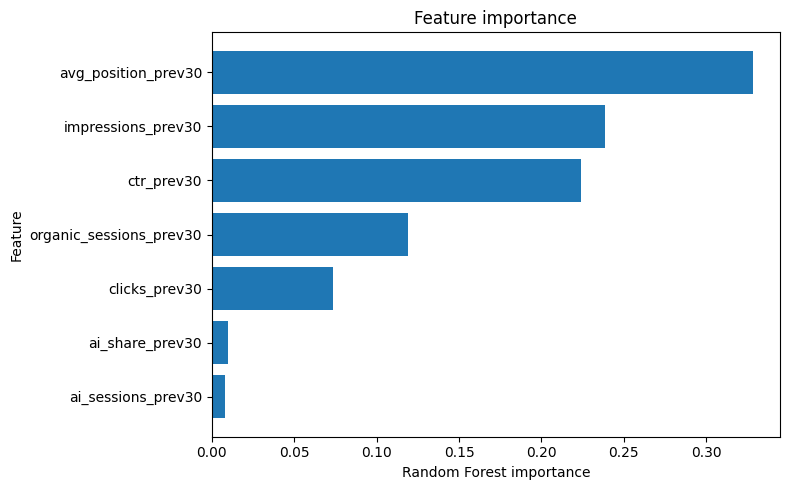

In [28]:
# ============================================================
# Section 4 — Step 24
# Feature importance chart
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Feature importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Limitations

This analysis is an observational and directional modeling exercise rather than a causal study of search ranking behavior. The target measures whether observed impressions declined by more than 20% between two adjacent 30-day windows; it does not identify why a decline occurred.

The client-level validation design reduces the risk of evaluating the model on clients seen during training, but the results still depend on the available clients, observation windows, and feature definitions. The Random Forest did not outperform the majority-class baseline on the held-out clients, so the current feature set should not be treated as a reliable production prediction system.

The features are aggregate search and engagement signals and do not contain page semantics, content quality judgments, algorithm-update information, or other external factors that could influence performance. Therefore, feature importance should be interpreted as model association, not causal evidence.

The results support prioritization and further investigation, not claims about Google's ranking algorithm or guaranteed traffic outcomes.

In [29]:
# ============================================================
# Section 5 — Step 25
# Quantify model performance relative to baseline
# ============================================================

comparison = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "random_forest": [
        model_accuracy,
        model_precision,
        model_recall,
        model_f1
    ]
})

comparison["model_minus_baseline"] = (
    comparison["random_forest"]
    - comparison["baseline"]
)

print(comparison.round(3).to_string(index=False))

   metric  baseline  random_forest  model_minus_baseline
 Accuracy     0.603          0.542                -0.061
Precision     0.603          0.648                 0.044
   Recall     1.000          0.530                -0.470
       F1     0.753          0.583                -0.170


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [30]:
# ============================================================
# Section 6 — Step 26
# Generate decision-support scores
# ============================================================

recommendations = model_data.iloc[test_idx].copy()

recommendations["decline_probability"] = y_prob

recommendations["predicted_decline"] = y_pred

# Higher score = higher priority for review.
recommendations["priority_score"] = (
    recommendations["decline_probability"] * 100
)

recommendations = recommendations.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

print("Ranked recommendation rows:", f"{len(recommendations):,}")

recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "decline_probability",
        "priority_score",
        "impressions_prev30",
        "avg_position_prev30",
        "ctr_prev30"
    ]
].head(20)

Ranked recommendation rows: 20,844


,client_hash_id,content_hash_id,decline_probability,priority_score,impressions_prev30,avg_position_prev30,ctr_prev30
0,client_73cda7b4e4f265ea,content_c90eabe47f856f9d,1.000,100.0,976.0,45.561254,0.001025
1,client_73cda7b4e4f265ea,content_26ba9f22fcd39bea,0.995,99.5,4481.0,22.971789,0.000446
2,client_73cda7b4e4f265ea,content_092968080dedb8e1,0.990,99.0,1867.0,31.674668,0.000536
3,client_73cda7b4e4f265ea,content_0fcb2a226fc28f0d,0.990,99.0,3443.0,20.773227,0.000290
4,client_73cda7b4e4f265ea,content_75aaff55be24ea2b,0.990,99.0,1703.0,29.652382,0.000587
5,client_73cda7b4e4f265ea,content_56a2187a1d83cc3b,0.990,99.0,2254.0,33.564018,0.000887
6,client_73cda7b4e4f265ea,content_fcfac2bd6ecac8a0,0.990,99.0,139.0,35.129193,0.000000
7,client_73cda7b4e4f265ea,content_98eec21924720a26,0.985,98.5,534.0,21.958920,0.001873
8,client_73cda7b4e4f265ea,content_7155b905caab17ae,0.980,98.0,1158.0,40.380173,0.001727
9,client_73cda7b4e4f265ea,content_d011ec9d7e482fc7,0.980,98.0,499.0,24.522359,0.002004


In [31]:
# ============================================================
# Section 6 — Step 27
# Create human-readable reason codes
# ============================================================

def make_reason_codes(row):
    reasons = []

    if row["avg_position_prev30"] >= 20:
        reasons.append("low_visibility")

    if row["ctr_prev30"] < 0.02:
        reasons.append("low_ctr")

    if row["impressions_prev30"] < 500:
        reasons.append("low_impression_volume")

    if row["organic_sessions_prev30"] == 0:
        reasons.append("no_organic_sessions")

    if row["ai_sessions_prev30"] > 0:
        reasons.append("ai_referral_signal")

    if not reasons:
        reasons.append("model_risk_only")

    return ", ".join(reasons)


recommendations["reason_codes"] = recommendations.apply(
    make_reason_codes,
    axis=1
)

recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "priority_score",
        "reason_codes"
    ]
].head(20)

,client_hash_id,content_hash_id,priority_score,reason_codes
0,client_73cda7b4e4f265ea,content_c90eabe47f856f9d,100.0,"low_visibility, low_ctr"
1,client_73cda7b4e4f265ea,content_26ba9f22fcd39bea,99.5,"low_visibility, low_ctr"
2,client_73cda7b4e4f265ea,content_092968080dedb8e1,99.0,"low_visibility, low_ctr"
3,client_73cda7b4e4f265ea,content_0fcb2a226fc28f0d,99.0,"low_visibility, low_ctr"
4,client_73cda7b4e4f265ea,content_75aaff55be24ea2b,99.0,"low_visibility, low_ctr"
5,client_73cda7b4e4f265ea,content_56a2187a1d83cc3b,99.0,"low_visibility, low_ctr"
6,client_73cda7b4e4f265ea,content_fcfac2bd6ecac8a0,99.0,"low_visibility, low_ctr, low_impression_volume"
7,client_73cda7b4e4f265ea,content_98eec21924720a26,98.5,"low_visibility, low_ctr"
8,client_73cda7b4e4f265ea,content_7155b905caab17ae,98.0,"low_visibility, low_ctr"
9,client_73cda7b4e4f265ea,content_d011ec9d7e482fc7,98.0,"low_visibility, low_ctr, low_impression_volume"


In [32]:
# ============================================================
# Section 6 — Step 28
# Convert reason codes into an action playbook
# ============================================================

def recommend_action(row):
    reasons = row["reason_codes"]

    if "low_visibility" in reasons and "low_ctr" in reasons:
        return "Review visibility and SERP presentation"

    if "low_ctr" in reasons:
        return "Review title/snippet and search-intent alignment"

    if "low_visibility" in reasons:
        return "Review content targeting and discoverability"

    if "low_impression_volume" in reasons:
        return "Monitor before major intervention"

    if "no_organic_sessions" in reasons:
        return "Review organic discoverability"

    if "ai_referral_signal" in reasons:
        return "Monitor AI referral signal"

    return "Review content performance"


recommendations["recommended_action"] = recommendations.apply(
    recommend_action,
    axis=1
)

ranked_recommendations = recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "priority_score",
        "decline_probability",
        "reason_codes",
        "recommended_action"
    ]
].head(50)

ranked_recommendations

,client_hash_id,content_hash_id,priority_score,decline_probability,reason_codes,recommended_action
0,client_73cda7b4e4f265ea,content_c90eabe47f856f9d,100.0,1.000,"low_visibility, low_ctr",Review visibility and SERP presentation
1,client_73cda7b4e4f265ea,content_26ba9f22fcd39bea,99.5,0.995,"low_visibility, low_ctr",Review visibility and SERP presentation
2,client_73cda7b4e4f265ea,content_092968080dedb8e1,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
3,client_73cda7b4e4f265ea,content_0fcb2a226fc28f0d,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
4,client_73cda7b4e4f265ea,content_75aaff55be24ea2b,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
5,client_73cda7b4e4f265ea,content_56a2187a1d83cc3b,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
6,client_73cda7b4e4f265ea,content_fcfac2bd6ecac8a0,99.0,0.990,"low_visibility, low_ctr, low_impression_volume",Review visibility and SERP presentation
7,client_73cda7b4e4f265ea,content_98eec21924720a26,98.5,0.985,"low_visibility, low_ctr",Review visibility and SERP presentation
8,client_73cda7b4e4f265ea,content_7155b905caab17ae,98.0,0.980,"low_visibility, low_ctr",Review visibility and SERP presentation
9,client_73cda7b4e4f265ea,content_d011ec9d7e482fc7,98.0,0.980,"low_visibility, low_ctr, low_impression_volume",Review visibility and SERP presentation


In [33]:
# ============================================================
# Section 6 — Step 29
# Final ranked action playbook
# ============================================================

final_action_table = recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "priority_score",
        "decline_probability",
        "reason_codes",
        "recommended_action"
    ]
].head(25).copy()

final_action_table.insert(
    0,
    "rank",
    range(1, len(final_action_table) + 1)
)

print("Top 25 decision-support recommendations:")
final_action_table

Top 25 decision-support recommendations:


,rank,client_hash_id,content_hash_id,priority_score,decline_probability,reason_codes,recommended_action
0,1,client_73cda7b4e4f265ea,content_c90eabe47f856f9d,100.0,1.000,"low_visibility, low_ctr",Review visibility and SERP presentation
1,2,client_73cda7b4e4f265ea,content_26ba9f22fcd39bea,99.5,0.995,"low_visibility, low_ctr",Review visibility and SERP presentation
2,3,client_73cda7b4e4f265ea,content_092968080dedb8e1,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
3,4,client_73cda7b4e4f265ea,content_0fcb2a226fc28f0d,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
4,5,client_73cda7b4e4f265ea,content_75aaff55be24ea2b,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
5,6,client_73cda7b4e4f265ea,content_56a2187a1d83cc3b,99.0,0.990,"low_visibility, low_ctr",Review visibility and SERP presentation
6,7,client_73cda7b4e4f265ea,content_fcfac2bd6ecac8a0,99.0,0.990,"low_visibility, low_ctr, low_impression_volume",Review visibility and SERP presentation
7,8,client_73cda7b4e4f265ea,content_98eec21924720a26,98.5,0.985,"low_visibility, low_ctr",Review visibility and SERP presentation
8,9,client_73cda7b4e4f265ea,content_7155b905caab17ae,98.0,0.980,"low_visibility, low_ctr",Review visibility and SERP presentation
9,10,client_73cda7b4e4f265ea,content_d011ec9d7e482fc7,98.0,0.980,"low_visibility, low_ctr, low_impression_volume",Review visibility and SERP presentation


In [34]:
# ============================================================
# Section 6 — Step 30
# summary
# ============================================================

action_summary = (
    recommendations
    .groupby("recommended_action")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="content_count")
)

print(action_summary.to_string(index=False))

                              recommended_action  content_count
Review title/snippet and search-intent alignment          18180
         Review visibility and SERP presentation           2390
               Monitor before major intervention            212
                      Review content performance             53
    Review content targeting and discoverability              8
                      Monitor AI referral signal              1


## 7. Artifacts the paper embeds

The paper uses a small set of reproducible artifacts: a model-versus-baseline comparison, a confusion matrix, feature importance, and a ranked action table. These artifacts are intended to make the evaluation transparent and connect the modeling results to practical review priorities.

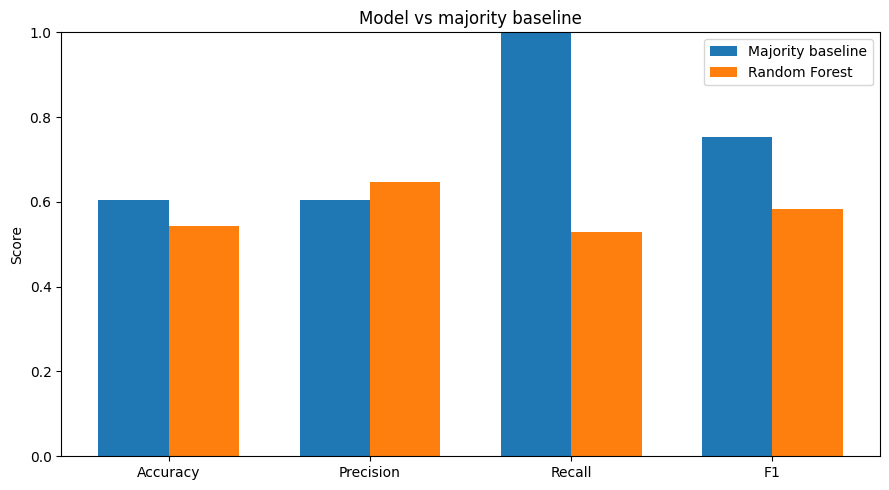

In [35]:
# ============================================================
# Section 7 — Step 31
# Model vs baseline chart
# ============================================================

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

baseline_values = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
]

model_values = [
    model_accuracy,
    model_precision,
    model_recall,
    model_f1
]

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Majority baseline"
)

plt.bar(
    x + width / 2,
    model_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics_to_plot)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model vs majority baseline")
plt.legend()
plt.tight_layout()
plt.show()

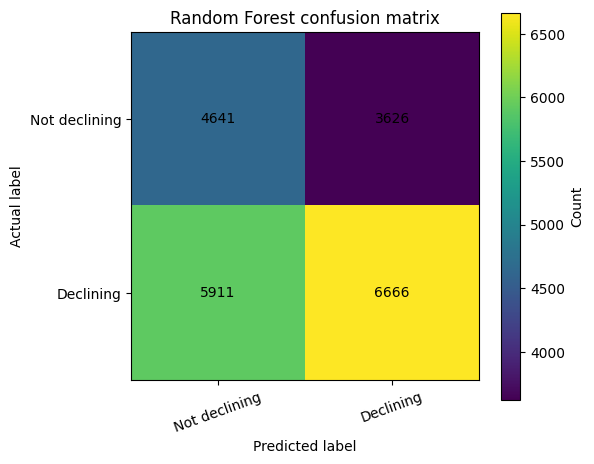

In [36]:
# ============================================================
# Section 7 — Step 32
# Confusion matrix visualization
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.xticks(
    [0, 1],
    ["Not declining", "Declining"],
    rotation=20
)

plt.yticks(
    [0, 1],
    ["Not declining", "Declining"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Count")
plt.tight_layout()
plt.show()

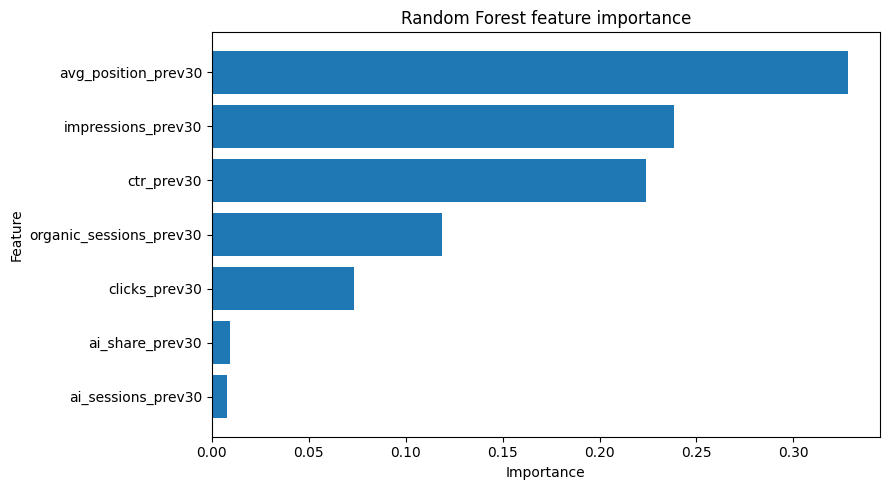

In [37]:
# ============================================================
# Section 7 — Step 33
# Paper-ready feature importance
# ============================================================

importance_plot = importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest feature importance")

plt.tight_layout()
plt.show()

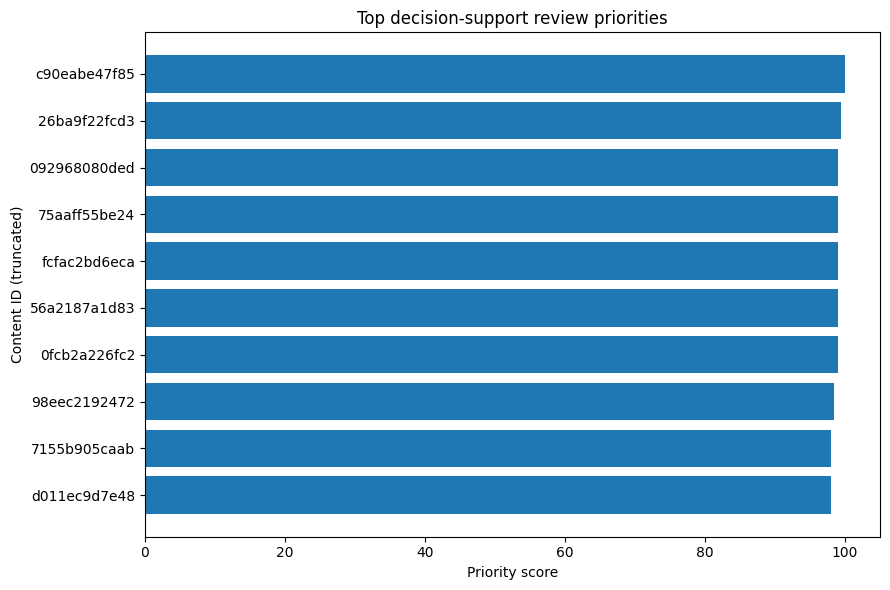

In [38]:
# ============================================================
# Section 7 — Step 34
# Top decision-support priorities
# ============================================================

top10 = recommendations.head(10).copy()

top10 = top10.sort_values(
    "priority_score",
    ascending=True
)

labels = (
    top10["content_hash_id"]
    .str.replace("content_", "", regex=False)
    .str[:12]
)

plt.figure(figsize=(9, 6))

plt.barh(
    labels,
    top10["priority_score"]
)

plt.xlabel("Priority score")
plt.ylabel("Content ID (truncated)")
plt.title("Top decision-support review priorities")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# Section 7 — Step 35
# Final paper artifact table
# ============================================================

paper_results = pd.DataFrame({
    "Metric": [
        "Test rows",
        "Test clients",
        "Test declining rate",
        "Baseline accuracy",
        "Model accuracy",
        "Baseline F1",
        "Model F1",
        "Model PR-AUC"
    ],
    "Value": [
        len(X_test),
        groups_test.nunique(),
        y_test.mean(),
        baseline_accuracy,
        model_accuracy,
        baseline_f1,
        model_f1,
        model_pr_auc
    ]
})

paper_results["Value"] = paper_results["Value"].round(3)

paper_results

,Metric,Value
0,Test rows,20844.000
1,Test clients,10.000
2,Test declining rate,0.603
3,Baseline accuracy,0.603
4,Model accuracy,0.542
5,Baseline F1,0.753
6,Model F1,0.583
7,Model PR-AUC,0.650


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
